Group #3

1. Get the 15 variables from this raster for all Peru departments polygons. This is the link where shapefiles are located. This is the link of the source raster. The values should be the percentage of district area cover by this specific Morphological Settlement Zone.

In [ ]:
!pip install rasterio

In [ ]:
%pip install geopandas matplotlib shapely rasterio numpy pandas sklearn-xarray -q

In [ ]:
!pip install ipywidgets

In [ ]:
!jupyter labextension install @jupyter-widgets/jupyterlab-manager

In [ ]:
!pip install rasterstats

In [ ]:
%pip install geopandas matplotlib shapely rasterio numpy pandas sklearn-xarray -q

In [ ]:
%pip install git+https://github.com/jgrss/geowombat  -q

In [ ]:
import geopandas as gpd
from rasterstats import zonal_stats
import pandas as pd
import geowombat as gw

import geopandas as gpd

from rasterio.merge import merge
from rasterio.plot import show
from shapely.geometry import mapping
import rasterio

from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

import os
from rasterio.mask import mask

In [ ]:
#Utilizando google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
import geopandas as gpd

In [ ]:
# Establecemos la ruta
shapefile_path = '/content/drive/MyDrive/group3_ass10_10/INEI_LIMITE_DEPARTAMENTAL/INEI_LIMITE_DEPARTAMENTAL.shp'

# Leemos el shapefile
departments = gpd.read_file('/content/drive/MyDrive/group3_ass10_10/INEI_LIMITE_DEPARTAMENTAL/INEI_LIMITE_DEPARTAMENTAL.shp')

# Establemos la proyección esapcial
# Rasters en 'esri:54009' (ponemos un supuesto)
departments = departments.to_crs('esri:54009')

print(departments.head())

In [ ]:
import rasterio
from rasterio.merge import merge
import rasterio
from rasterio.mask import mask
import pandas as pd

In [ ]:
import glob

# Definimos el camino base donde se encuentran tus archivos .tif
base_path = '/content/drive/MyDrive/Assign 10/tif_files/'

# Utilizamos glob para encontrar todos los archivos
raster_files = glob.glob(base_path + '*.tif')

for file in raster_files:
    print(file)

In [ ]:
from rasterstats import zonal_stats
# Creamos lista para nuestri rusteer
all_stats = []

# Creamos un loop sobre cada archivo raster
for raster_path in raster_files:
    # Ubicando las estadísticas zonales
    stats = zonal_stats(departments, raster_path, stats="count sum", categorical=True, all_touched=True)
    # Convirtiendo a dataframe
    stats_df = pd.DataFrame(stats)
    # Concatenamos con la geometría y la información de los departamentos
    df = pd.concat([departments.reset_index(drop=True), stats_df], axis=1)
    all_stats.append(df)

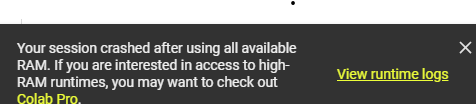

In [ ]:
#Solicita Colab Pro
#El código sse cuelga, presentó el error con colab regular